In [28]:
1+1

2

## Basic chatbot using graphAPI

In [29]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages #this is a reducer
#the work of a reducer is to append information inside state rather than replace it


 

In [30]:
class State(TypedDict):
    messages:Annotated[list,add_messages] #here the messagesmake thelist and it uses reducer



In [31]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [32]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b")


In [33]:
#this bascally is my node functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [34]:
graph_builder=StateGraph(State)

#adding node
graph_builder.add_node("llmchatbot", chatbot) 

#adding edge
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

In [35]:
#compile graph

graph=graph_builder.compile()

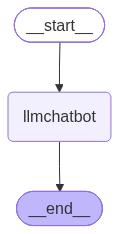

In [36]:
## visual of grapoh

from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
#needed to put mesages to invoke 
response = graph.invoke({"messages":"Yo"})

In [38]:
response['messages'][-1].content

'Hey there! What’s up?'

In [39]:
#more ways to stream 
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I help you today?


## Chatbot with tool


In [40]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 3)
response = tool.invoke("what is langgraph")


In [41]:
response

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [42]:
#custom function

def multiply(a:int , b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [43]:
tools = [tool,multiply]

In [44]:
llm_with_tools = llm.bind_tools(tools)

In [45]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1175bf890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1176382d0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted res

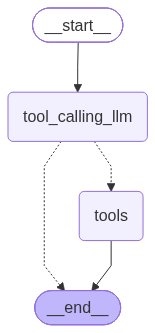

In [46]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#state
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#node
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges 
builder.add_edge(START,"tool_calling_llm") #tool
#here i need conditional edge that whether to call tool or not 
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [47]:
response = graph.invoke({"messages":"what is current job market"})

In [48]:
response['messages'][-1].content

'{"query": "current job market 2024 unemployment rate trends sectors remote work", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.facebook.com/groups/2424166204261413/posts/28618779701040039", "title": "Current US job market trends and outlook for 2024", "content": "Here\'s a breakdown: - *Job Market Trends:* - The US added 139,000 jobs in May, with a steady unemployment rate of 4.2%. Healthcare, leisure, and hospitality", "score": 0.7752821, "raw_content": null, "id": "60cc93-00"}, {"url": "https://www.linkedin.com/posts/linda-nazareth-7381949_work-economy-entrylevel-activity-7490453236819292160-ayhz", "title": "Remote work hurting new graduates job prospects", "content": "The researchers also cited figures showing that from 2017 to 2019 and from 2022 to 2024, younger workers in \'remotable\' jobs saw their unemployment rates rise", "score": 0.74563974, "raw_content": null, "id": "027e65-01"}, {"url": "https://www.y-axis.com/job-outlook/usa

In [49]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is current job market
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_4dcf85cc-dccf-41e7-9629-62f0b0d6761f)
 Call ID: fc_4dcf85cc-dccf-41e7-9629-62f0b0d6761f
  Args:
    query: current job market 2024 unemployment rate trends sectors remote work
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "current job market 2024 unemployment rate trends sectors remote work", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.facebook.com/groups/2424166204261413/posts/28618779701040039", "title": "Current US job market trends and outlook for 2024", "content": "Here's a breakdown: - *Job Market Trends:* - The US added 139,000 jobs in May, with a steady unemployment rate of 4.2%. Healthcare, leisure,

In [50]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


In [51]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_3251c6cb-d34e-4e99-8327-061fd29c2db0)
 Call ID: fc_3251c6cb-d34e-4e99-8327-061fd29c2db0
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: multiply

50


### yeah so here without react, it just used one tool nothing else

In [52]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_436349c8-fee1-4281-8152-1d08ee428d25)
 Call ID: fc_436349c8-fee1-4281-8152-1d08ee428d25
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://carcc.org/2026/08/27/all-things-ai-september-2026", "title": "All Things AI – September 2026 – Campus Research Computing Consortium (CaRCC)", "content": "NSF AI Datasets Program (NSF 26-512) — Full proposals due November 4. NSF has committed up to $100 million to making existing scientific datasets AI-ready — funding no new data col

### now we use the react agent architecture

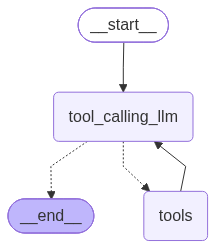

In [55]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [56]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_755ed3db-3835-4571-b09a-2c220a35bc4c)
 Call ID: fc_755ed3db-3835-4571-b09a-2c220a35bc4c
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.globalxetfs.com/articles/the-next-big-theme-august-2026", "title": "The Next Big Theme: August 2026", "content": "Alibaba unveiled Qwen3.8-Max, its largest and most capable AI model to date. The 2.4 trillion-parameter model is designed for enterprise workloads, including coding, research, multimodal reasoning, and long-horizon task e